In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
Y = iris.target
print(X.shape,
Y.shape)

(150, 4) (150,)


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
feature_names_list = iris.feature_names
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(x_scaled, columns=feature_names_list)
display(df_scaled.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


[600.0, 222.36170496502302, 191.02473685317958, 114.35407164049778, 91.04766991109526, 81.55075699571756, 80.77773933734285, 64.42674849482273, 55.70690047933695, 51.121095396505545]


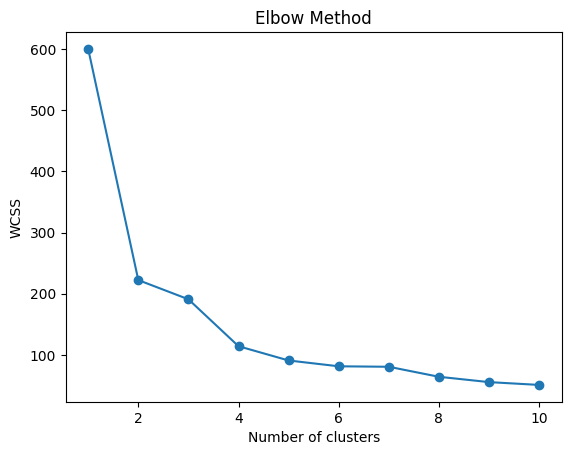

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(x_scaled)
df_scaled['Cluster'] = y_kmeans
print(df_scaled.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


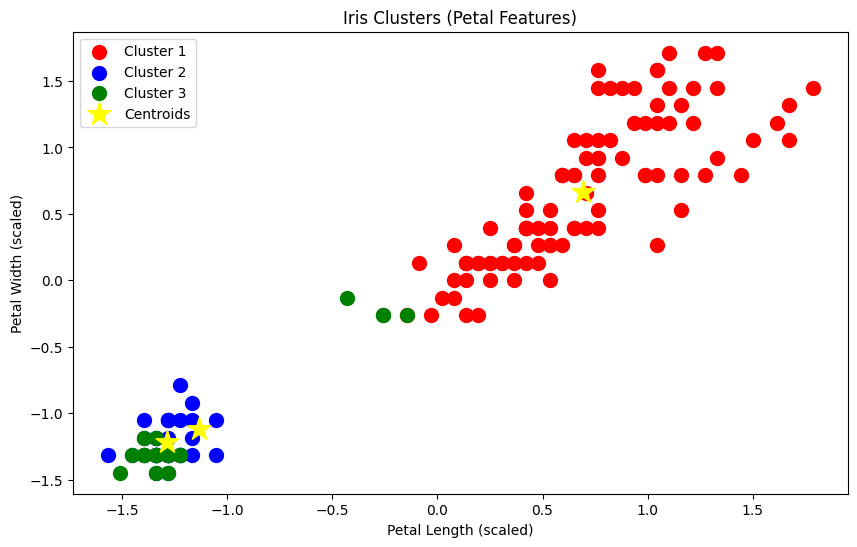

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x_scaled[y_kmeans == 0, 2], x_scaled[y_kmeans == 0, 3], s=100, c='red', label='Cluster 1')
plt.scatter(x_scaled[y_kmeans == 1, 2], x_scaled[y_kmeans == 1, 3], s=100, c='blue', label='Cluster 2')
plt.scatter(x_scaled[y_kmeans == 2, 2], x_scaled[y_kmeans == 2, 3], s=100, c='green', label='Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s=300, c='yellow', label='Centroids', marker='*')
plt.title('Iris Clusters (Petal Features)')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.show()


In [ ]:
data = {
    'sepal length (cm)': [5.1, 6.2, 7.5],
    'sepal width (cm)':  [3.5, 2.8, 3.0],
    'petal length (cm)': [1.4, 4.8, 6.2],
    'petal width (cm)':  [0.2, 1.8, 2.2]
}

test_df = pd.DataFrame(data)

test_scaled = scaler.transform(test_df)


test_clusters = kmeans.predict(test_scaled)


test_df['Assigned_Cluster'] = test_clusters

print("--- Manual Test Data Results ---")
display(test_df)

--- Manual Test Data Results ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Assigned_Cluster
0,5.1,3.5,1.4,0.2,1
1,6.2,2.8,4.8,1.8,0
2,7.5,3.0,6.2,2.2,0
